# Particle Classification with Video Crops + Graph Neural Network

Extends the trajectory-graph classifier with per-node image appearance.  Each velocity node in the graph now carries a 24×24-pixel ROCS crop extracted at its detection frame.  The `ImageGraphConv` model fuses these crops (via a small CNN) with the motion-feature GNN.

In [1]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import lightning as L
import matplotlib.pyplot as plt
from lightning.pytorch.callbacks import ModelCheckpoint
from torch_geometric.data import Batch
from sklearn.metrics import classification_report, confusion_matrix

import deeplay as dl

from trajan.custom_models.magik import ImageGraphConv
from trajan.data import TracksDataFrame
from trajan.dataset import VideoGraphDataset, build_video_graph_dataset
from trajan.graph import GraphFromTrajectories
from trajan.visualization import plot_confusion_matrix

## Data

Load `video_tracks.csv` (same schema as `tracks.csv` with an extra `crop_idx` column) and the companion `video_crops.npy` array of shape `(N, 24, 24)`.  The `crop_idx` values index directly into the crops array, so we always pass the **full** crops array to both the train and validation datasets — the split only affects which recording rows each dataset sees.

In [3]:
df = pd.read_csv(os.path.join("data", "cytoplasmic", "video_tracks.csv"))
crops = np.load(os.path.join("data", "cytoplasmic", "video_crops.npy"))

data = TracksDataFrame(df, frame_rate=10)
data_description = data.describe_tracks()

# Use alphabetical order so labels match pd.Categorical codes used in graph building.
display_labels = sorted(data["type"].unique())
num_classes = len(display_labels)
print(f"\nCrops array: {crops.shape}  dtype={crops.dtype}")
print(f"Classes ({num_classes}): {display_labels}")

particle_types: ['endosome', 'Golgi', 'Postgolgitoendosome']
frame_rate: 10

endosome:
  n_recordings: 19
  recording_ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
  n_tracks: 213
  avg_track_len: 124.4

Golgi:
  n_recordings: 7
  recording_ids: [20, 21, 22, 23, 24, 25, 26]
  n_tracks: 103
  avg_track_len: 142.37

Postgolgitoendosome:
  n_recordings: 11
  recording_ids: [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
  n_tracks: 131
  avg_track_len: 131.94

Crops array: (58445, 24, 24)  dtype=float32
Classes (3): ['Golgi', 'Postgolgitoendosome', 'endosome']


## Train / Validation Split and Graph Construction

Recordings are split at the **recording level** (stratified by class) so no trajectory leaks between splits.  The graph builder and velocity std are estimated from training data only.  `build_video_graph_dataset` mirrors `GraphFromTrajectories.__call__` but also attaches a `crop_idx` tensor to every velocity node.

In [4]:
test_size = 0.25
seed = 6
Dt_range = (50, 120)
max_frame_gap = 3

train_data, val_data = data.split_train_test(test_size=test_size, seed=seed)

graph_builder, velocity_std = GraphFromTrajectories.from_tracks(
    train_data, max_frame_gap, frame_rate=10
)

train_graphs = build_video_graph_dataset(
    graph_builder, train_data, target_column="type", split_tracks=True
)
val_graphs = build_video_graph_dataset(
    graph_builder, val_data, target_column="type", split_tracks=True
)

print(f"Train graphs: {len(train_graphs)}  |  Val graphs: {len(val_graphs)}")

Train graphs: 333  |  Val graphs: 254


## Datasets and DataLoaders

`VideoGraphDataset.__getitem__` returns a `(Data, imgs)` tuple, so we use a custom `collate_video` function with a standard `torch.utils.data.DataLoader`.  The collate function:
- merges the individual `Data` objects into a single `Batch` (PyG)
- concatenates the per-node crop tensors along dim 0 so `imgs.shape = (Σ N_nodes, 1, H, W)`

In [5]:
def collate_video(batch):
    """Collate (Data, imgs) pairs into a PyG Batch and a stacked crop tensor."""
    graphs, imgs_list = zip(*batch)
    return Batch.from_data_list(list(graphs)), torch.cat(imgs_list, dim=0)


train_dataset_size = 2 * int(sum(len(g.x) for g in train_graphs) / np.mean(Dt_range))
val_dataset_size   = 5 * int(sum(len(g.x) for g in val_graphs)   / np.mean(Dt_range))
train_batch_size = 16
val_batch_size   = 256

train_dataset = VideoGraphDataset(
    train_graphs, crops, Dt_range, train_dataset_size, velocity_std,
    target="global", sample_balanced=True,
)
val_dataset = VideoGraphDataset(
    val_graphs, crops, Dt_range, val_dataset_size, velocity_std,
    target="global",
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=train_batch_size, shuffle=True, collate_fn=collate_video
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=val_batch_size, collate_fn=collate_video
)

print(f"Train batches/epoch: {len(train_loader)}")
print(f"Val   batches/epoch: {len(val_loader)}")

# Quick sanity check on one batch
graph_batch, imgs_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  graph.x:    {graph_batch.x.shape}")
print(f"  imgs:       {imgs_batch.shape}  [{imgs_batch.min():.3f}, {imgs_batch.max():.3f}]")
print(f"  graph.y:    {graph_batch.y.shape}")

Train batches/epoch: 47
Val   batches/epoch: 6

Sample batch:
  graph.x:    torch.Size([1089, 2])
  imgs:       torch.Size([1089, 1, 24, 24])  [0.000, 1.000]
  graph.y:    torch.Size([16])


## Model

`ImageGraphConv` extends `GraphToGlobalMPM` with a small CNN branch.  For each velocity node the CNN embeds the 24×24 ROCS crop into a vector of size `encoder_dimension` via a small CNN + linear projection.  The GNN encoder first encodes the `(vx, vy)` velocity features to `encoder_dimension`, then the image embedding is added element-wise before the message-passing backbone.  After global mean-pooling the graph-level embedding is concatenated with `(local_scale, persistence)` before the classification head.

In [6]:
encoder_dimension = 96
num_blocks = 4
lr = 1e-4
wd = 1e-5

image_graph_conv = ImageGraphConv(
    [encoder_dimension] * num_blocks,
    out_features=num_classes,
    out_activation=nn.Softmax(dim=1),
)
# graph_features (local_scale, persistence) are appended before the head
image_graph_conv.head.configure(in_features=encoder_dimension + 2, out_features=num_classes)
image_graph_conv = image_graph_conv.create()

In [7]:
class VideoGraphClassifier(L.LightningModule):
    """LightningModule wrapping ImageGraphConv for (graph, imgs) batches."""

    def __init__(self, model, lr=1e-4, wd=1e-5):
        super().__init__()
        self.model = model
        self.loss_fn = nn.CrossEntropyLoss()
        self.lr = lr
        self.wd = wd

    def forward(self, graph, imgs):
        return self.model(graph, imgs)

    def _step(self, batch, stage):
        graph, imgs = batch
        y_hat = self(graph, imgs)
        loss = self.loss_fn(y_hat, graph.y)
        self.log(f"{stage}_loss", loss, batch_size=graph.num_graphs, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._step(batch, "val")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.wd)


classifier = VideoGraphClassifier(image_graph_conv, lr=lr, wd=wd)

In [8]:
run_dir = os.path.join(repo_root, "notebooks", "runs_video")

checkpoint_cb = ModelCheckpoint(
    dirpath=run_dir,
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)
callbacks = [checkpoint_cb]

## Training

In [9]:
num_epochs = 15

trainer = L.Trainer(
    max_epochs=num_epochs,
    accelerator="auto",
    callbacks=callbacks,
)

trainer.fit(classifier, train_loader, val_loader)

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/guillemguigoicorominas/Desktop/Guillem/UVic/PhD/repositories/personal/ParticleClassification/notebooks/runs_video exists and is not empty.
/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:543: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ ImageGraphConv   │ 15.1 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 15.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 80                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/trainer/conn
ectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/trainer/conn
ectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/loops/fit_lo
op.py:317: The number of training batches (47) is smaller than the logging interval Trainer(log_every_n_steps=50). 
Set a lower value for log_every_n_steps if you want to see logs for the training epoch.

In [10]:
metrics = trainer.logged_metrics
train_losses = [v for k, v in trainer.callback_metrics.items() if "train" in k]

# Plot via Lightning's history if available, otherwise use logged metrics
try:
    fig, ax = trainer.history.plot()
except AttributeError:
    # Fallback: retrieve from CSV logger or just show best val loss
    pass

best_val_loss = checkpoint_cb.best_model_score.item() if checkpoint_cb.best_model_score is not None else float("inf")
print(f"Best val loss: {best_val_loss:.4f}")

Best val loss: 1.0661


## Evaluation

Restore the best checkpoint weights and evaluate on the validation and training sets.

In [11]:
# Restore best checkpoint weights into the current classifier
best_ckpt = torch.load(checkpoint_cb.best_model_path, map_location="cpu")
classifier.load_state_dict(best_ckpt["state_dict"])
classifier.eval();

=== Validation set ===
                     precision    recall  f1-score   support

              Golgi       0.50      0.71      0.59       508
Postgolgitoendosome       0.59      0.61      0.60       515
           endosome       0.55      0.29      0.38       502

           accuracy                           0.54      1525
          macro avg       0.55      0.54      0.52      1525
       weighted avg       0.55      0.54      0.52      1525



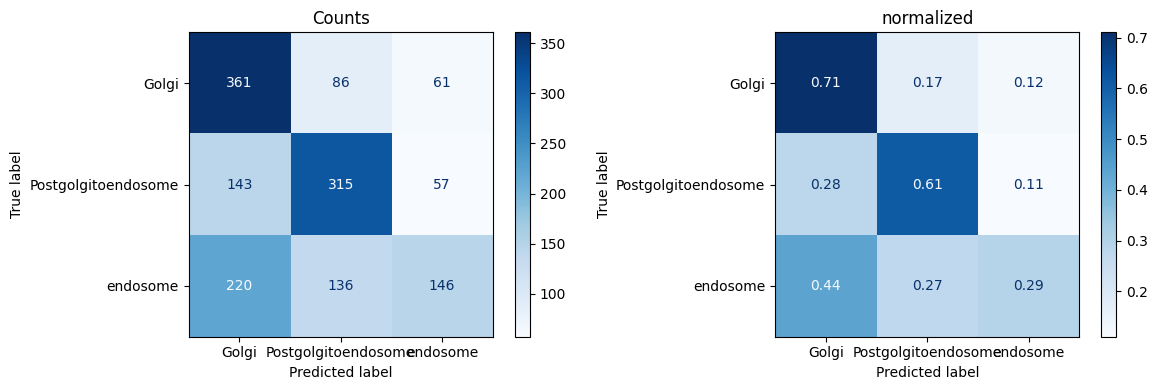

In [ ]:
truth, preds = [], []
with torch.no_grad():
    for graph, imgs in val_loader:
        y_hat = classifier(graph, imgs)
        preds.append(torch.argmax(y_hat, dim=1))
        truth.append(graph.y)

truth = torch.cat(truth).numpy()
preds = torch.cat(preds).numpy()

print("=== Validation set ===")
print(classification_report(truth, preds, target_names=display_labels))

cm = confusion_matrix(truth, preds)
cm_df = pd.DataFrame(cm, index=display_labels, columns=display_labels)
fig = plot_confusion_matrix(cm_df, display_labels)
plt.savefig('results_on_val_2')

=== Training set ===
                     precision    recall  f1-score   support

              Golgi       0.46      0.62      0.53       241
Postgolgitoendosome       0.57      0.81      0.67       249
           endosome       0.38      0.11      0.17       262

           accuracy                           0.50       752
          macro avg       0.47      0.51      0.46       752
       weighted avg       0.47      0.50      0.45       752



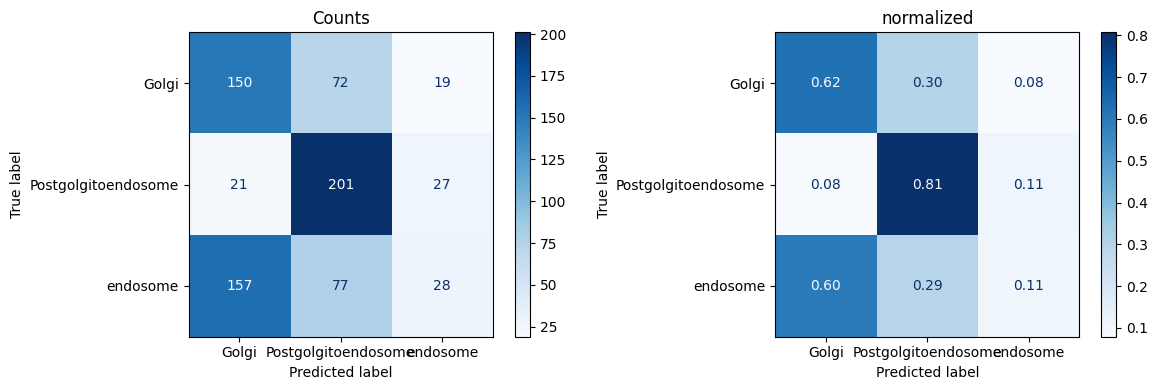

In [12]:
truth, preds = [], []
with torch.no_grad():
    for graph, imgs in train_loader:
        y_hat = classifier(graph, imgs)
        preds.append(torch.argmax(y_hat, dim=1))
        truth.append(graph.y)

truth = torch.cat(truth).numpy()
preds = torch.cat(preds).numpy()

print("=== Training set ===")
print(classification_report(truth, preds, target_names=display_labels))

cm = confusion_matrix(truth, preds)
cm_df = pd.DataFrame(cm, index=display_labels, columns=display_labels)
fig = plot_confusion_matrix(cm_df, display_labels)
plt.savefig('results_on_train_2')

In [ ]:
import shutil
shutil.rmtree(run_dir)